In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# XOR problem - Multi Layer Perceptron
w = [1, 1]
b= 0
x = np.array([ [0, 0], [0, 1], [1, 0], [1, 1] ])

In [4]:
def fn_and_gate(x):
    return ((np.matmul(x, w) + b) > 1).astype(np.int8)
y_and = fn_and_gate(x)
print(y_and)

[0 0 0 1]


In [5]:
def fn_or_gate(x):
    return ((x @ w + b) > 0).astype(np.int8)
y_or = fn_or_gate(x)
print(y_or)

[0 1 1 1]


In [6]:
def fn_nand_gate(x):
    return ((x @ w + b) <= 1).astype(np.int8)
y_nand = fn_nand_gate(x)
print(y_nand)

[1 1 1 0]


In [7]:
# XOR 게이트는 먼저 OR, NAND를 연산하고 둘을 AND로 하면 된다?
def fn_xor_gate(x):
    h1 = fn_or_gate(x)
    h2 = fn_nand_gate(x)
    # h1과 h2를 옆으로 붙여서 새로운 (4, 2) 행렬을 만듦
    new_x = np.column_stack((h1, h2))
    return fn_and_gate(new_x)
y_xor = fn_xor_gate(x)
print(y_xor)

[0 1 1 0]


In [8]:
df = pd.DataFrame({
    'x1':x[:,0], 
    'x2':x[:,1], 
    'AND':y_and, 
    'OR':y_or, 
    'NAND':y_nand, 
    'XOR':y_xor
    })
df

,x1,x2,AND,OR,NAND,XOR
0,0,0,0,0,1,0
1,0,1,0,1,1,1
2,1,0,0,1,1,1
3,1,1,1,1,0,0


In [9]:
y = np.column_stack([y_and, y_or, y_nand, y_xor])
print('forward 결과 ', y, sep='\n')

forward 결과 
[[0 0 1 0]
 [0 1 1 1]
 [0 1 1 1]
 [1 1 0 0]]


계단함수 통과
[[0 0 1 0]
 [0 1 1 1]
 [0 1 1 1]
 [1 1 0 0]]


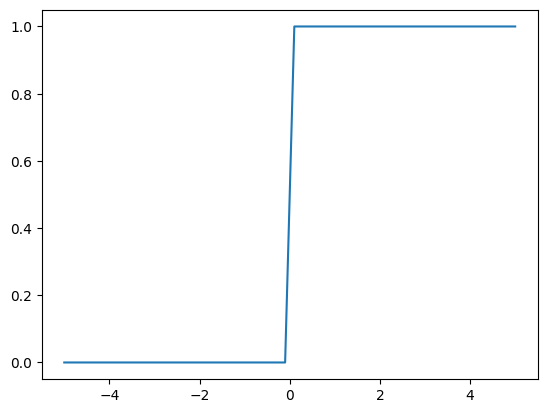

In [10]:
# 계단 함수
def fn_step(x):
    y = x > 0
    return y.astype(np.int8)
t = np.linspace(-5, 5)
step = fn_step(t)
print('계단함수 통과', fn_step(y),sep='\n')
plt.plot(t, step)
plt.show()


시그모이드 함수 통과
[[0.5   0.5   0.731 0.5  ]
 [0.5   0.731 0.731 0.731]
 [0.5   0.731 0.731 0.731]
 [0.731 0.731 0.5   0.5  ]]


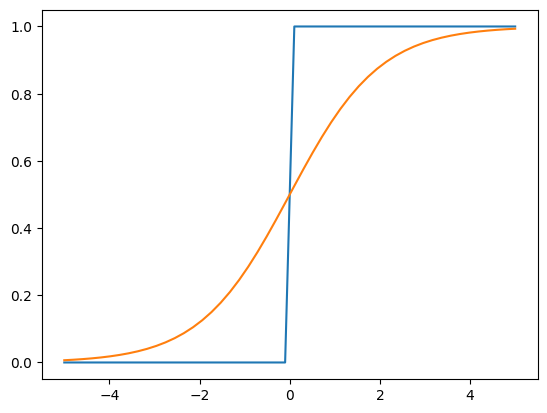

In [ ]:
# sigmoid 함수
def fn_sigmoid(x):
    y = 1 / (1 + np.exp(-x))
    return y
print('시그모이드 함수 통과', fn_sigmoid(y),sep='\n')
sig = fn_sigmoid(t)
plt.plot(t, step)
plt.plot(t, sig)
plt.show()

ReLU 함수 통과
[[0 0 1 0]
 [0 1 1 1]
 [0 1 1 1]
 [1 1 0 0]]


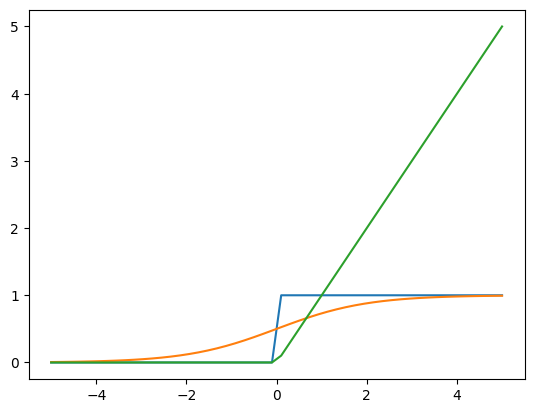

In [12]:
# ReLU 함수
def fn_relu(x):
    y = np.maximum(0, x)
    return y
print('ReLU 함수 통과', fn_relu(y),sep='\n')
relu = fn_relu(t)
plt.plot(t, step)
plt.plot(t, sig)
plt.plot(t, relu)
plt.show()


SoftMax 함수 통과
[[0.1749  0.10925 0.2969  0.1345 ]
 [0.1749  0.2969  0.2969  0.3657 ]
 [0.1749  0.2969  0.2969  0.3657 ]
 [0.4753  0.2969  0.10925 0.1345 ]]
요소의 총합 :  [1. 1. 1. 1.]


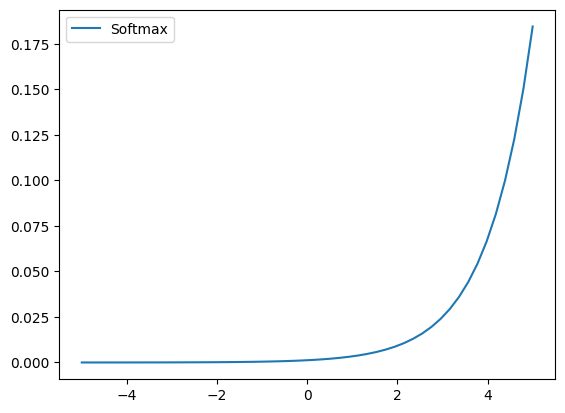

np.float64(1.0)

In [13]:
# softmax 함수
def fn_softmax(x):
    x_max = np.max(x, axis=0, keepdims=True)
    y = np.exp(x - x_max) / np.sum(np.exp(x - x_max), axis=0, keepdims=True)
    return y
print('SoftMax 함수 통과', fn_softmax(y),sep='\n')
print('요소의 총합 : ', np.sum(fn_softmax(y), axis=0))
softmax = fn_softmax(t)
# print(t)
# plt.plot(t, step, label='Step')
# plt.plot(t, sig, label='Sigmoid')
# plt.plot(t, relu, label='ReLU')
plt.plot(t, softmax, label='Softmax')
plt.legend()
plt.show()
np.sum(softmax)

In [18]:
import numpy as np

# XOR을 사용한 2층 신경망(순전파, 오류계산, 역전파)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([[0], [1], [1], [1]])
# 랜덤 고정
np.random.seed(42)
# 히든 뉴런의 갯수
hidden_size = 4

# 은닉층 함수 : ReLU
def fn_relu(X):
    return np.maximum(0, X)

# ReLU 미분
def fn_relu_deravative(X):
    return np.where(X > 0, 1, 0)

# 출력층 함수 : Sigmoid
def fn_sigmoid(X):
    return 1 / (1 + np.exp(-X))

# 시그모이드 미분
def fn_sigmoid_deravative(X):
    Y = fn_sigmoid(X)
    return Y * (1 - Y)

# 사용할 함수
act_fn = fn_sigmoid
act_fn_deravative = fn_sigmoid_deravative


# 입력층2 -> 은닉층(hidden_size) -> 출력층(1)
W1 = np.random.randn(2, hidden_size)   # 2 -> 2
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, 1)   # 2 -> 1 
b2 = np.zeros((1, 1))
lr = 0.3

# 학습
for epoch in range(1001):
    # 순전파
    Z1 = X @ W1 + b1        # (4, 2)
    A1 = act_fn(Z1)   # 은닉층 출력 (4, 2)
    Z2 = A1 @ W2 + b2     # (4, 1)
    A2 = fn_sigmoid(Z2)   # 최종 출력 (4, 1)
    # 오차 계산(MSE)
    loss = np.mean(0.5 * (Y - A2) ** 2)     # 미분 편의를 위해 1/2을 미리 곱해둠, (4, 1) -> 1(mean)
    
    # 역전파 : 오차를 줄이기 위한 가중치 변화 = 오차를 가중치로 편미분 (dL/dW)
    # 1. 은닉층으로 역전파 : 출력층으로 도달하기 위해 사용된 가중치가 오차에 얼마나 영향을 주었는가? (dL/dW2)
    # chain rule : dL/dW2 = dL/A2 * dA2/dZ2 * dZ2/dW2
    # dL/A2 : 오차에 활성화함수값이 끼친 영향
    dL_dA2 = A2 - Y     # (4, 1)
    # dA2/dZ2 : 활성화함수값에 은닉층 함수값이 끼친 영향
    dA2_dZ2 = fn_sigmoid_deravative(Z2) # (4, 1)
    # dL/dZ2 : 출력층 내부에서 일어난 변화가 오차에 끼친 영향 : elementwise
    delta2 = dL_dA2 * dA2_dZ2  # (4, 1)
    # 출력값을 가중치로 편미분 dZ2/dW2 = A1  # (4, 2)
    # 오차값에 가중치가 얼마나 기여하였는가?를 알기 위해 입력값 @ 최종오차신호 (역전파로 가중치를 수정하려면 가중치의 차원에 맞춰줌)
    dL_dW2 = A1.T @ delta2    # (2, 4) @ (4, 1) = (2, 1)
    # 편향의 경우 dL/db2 = dL/dA2 * dA2/dZ2 * dZ2/db2 = delta2 * 1 => 모든 요소에 영향을 끼쳤으므로 모든 행의 합계를 구함
    dL_db2 = np.sum(delta2, axis=0, keepdims=True)
   
    # 2. 입력층으로 역전파
    # chain rule : dL/dW1 = dL/dZ2 * dZ2/dA1 * dA1/dZ1 * dZ1/dW1
    # dL/dZ2는 위에 구했음 (4, 1)
    # dZ2/dA1 = W2  # (2, 1)
    # dL/dA1 = dL/dZ2 @ dZ2/dA1
    dL_dA1 = delta2 @ W2.T  # (4, 1) @ (1, 2) = (4, 2)
    # dA1/dZ1
    dA1_dZ1 = act_fn_deravative(Z1)  # (4, 2)
    # dL/dZ1 = dL/dA1 * dA1/dZ1 : 은닉층 내부에서 일어난 변화가 오차에 끼친 영향
    delta1 = dL_dA1 * dA1_dZ1  # (4, 2)
    # dL/dW1 = dL/dZ1 * dZ1/dW1
    # dZ1/dW1 = X  # (4, 2) => X.T # (2, 4)
    dL_dW1 = X.T @ delta1  # (2, 4) @ (4, 2) = (2, 2)
    # 편향 dL/db1 = dL/dA1 * dA1/dZ1 * dZ1/db1 = delta1 * 1
    dL_db1 = np.sum(delta1, axis=0, keepdims=True)
    
     # 경사하강법 : 가중치에서 dL/dw2를 빼줌(학습률 곱해서)
    W2 -= dL_dW2 * lr   # (2, 1)
    b2 -= dL_db2 * lr
    W1 -= dL_dW1 * lr  # (2, 2)
    b1 -= dL_db1 * lr

    pred_Y = (A2 > 0.5).astype(int)
    if (pred_Y == Y).all():
        print(f'{epoch}번 학습 후 정답 예측')
        print("\n[학습 결과]")
        print(A2)
        print("예측값 (0.5 기준): \n", pred_Y)
        break

    if epoch % 100 == 0:
        print(f"Epoch: {epoch}, Loss: {loss}")

Epoch: 0, Loss: 0.19357231416767784
Epoch: 100, Loss: 0.0729521036098388
180번 학습 후 정답 예측

[학습 결과]
[[0.49975052]
 [0.7777996 ]
 [0.75100683]
 [0.87229888]]
예측값 (0.5 기준): 
 [[0]
 [1]
 [1]
 [1]]


In [1]:
import MLP
import numpy as np

In [17]:
model = MLP.NeuralNetwork(input_size=2, hidden_size=8, output_size=1, learning_rate=0.5, activation_function='leaky_relu')
X = np.array([ [0, 0], [0, 1], [1, 0], [1, 1] ])    #(4, 2)
Y = np.array([[0], [1], [1], [0]])  # (4, 1)
for epoch in range(1000):
    A = model.forward(X)
    model.backward(Y)
    loss = np.mean(0.5 * (Y - A) ** 2)
    pred = (A > 0.5).astype(int)
    if (pred == Y).all():
        print(f'{epoch}번 학습 후 정답 예측')
        print("\n[학습 결과]")
        print(A)
        print("예측값 (0.5 기준): \n", pred)
        break

    if epoch % 100 == 0:
        print(f"Epoch: {epoch}, Loss: {loss}")

Using activation function: leaky_relu
Epoch: 0, Loss: 0.19516608637036514
Epoch: 100, Loss: 0.12724773846218534
Epoch: 200, Loss: 0.1257090583284165
Epoch: 300, Loss: 0.12539114950182856
Epoch: 400, Loss: 0.12526266371940534
Epoch: 500, Loss: 0.12519772266875967
Epoch: 600, Loss: 0.1251580191539141
Epoch: 700, Loss: 0.1251309980829658
Epoch: 800, Loss: 0.12511153537664285
Epoch: 900, Loss: 0.12509685048168617
